In [27]:
from ucimlrepo import fetch_ucirepo 
  
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, ConcatDataset


In [28]:
  
phishing_websites = fetch_ucirepo(id=327) 

In [29]:

X = phishing_websites.data.features.copy() 
y = phishing_websites.data.targets.copy()
y = y.replace({-1:0, 0:0})

In [30]:
X.columns.to_list()

['having_ip_address',
 'url_length',
 'shortining_service',
 'having_at_symbol',
 'double_slash_redirecting',
 'prefix_suffix',
 'having_sub_domain',
 'sslfinal_state',
 'domain_registration_length',
 'favicon',
 'port',
 'https_token',
 'request_url',
 'url_of_anchor',
 'links_in_tags',
 'sfh',
 'submitting_to_email',
 'abnormal_url',
 'redirect',
 'on_mouseover',
 'rightclick',
 'popupwindow',
 'iframe',
 'age_of_domain',
 'dnsrecord',
 'web_traffic',
 'page_rank',
 'google_index',
 'links_pointing_to_page',
 'statistical_report']

In [31]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   having_ip_address           11055 non-null  int64
 1   url_length                  11055 non-null  int64
 2   shortining_service          11055 non-null  int64
 3   having_at_symbol            11055 non-null  int64
 4   double_slash_redirecting    11055 non-null  int64
 5   prefix_suffix               11055 non-null  int64
 6   having_sub_domain           11055 non-null  int64
 7   sslfinal_state              11055 non-null  int64
 8   domain_registration_length  11055 non-null  int64
 9   favicon                     11055 non-null  int64
 10  port                        11055 non-null  int64
 11  https_token                 11055 non-null  int64
 12  request_url                 11055 non-null  int64
 13  url_of_anchor               11055 non-null  int64
 14  links_

In [32]:
y.value_counts()

result
1         6157
0         4898
Name: count, dtype: int64

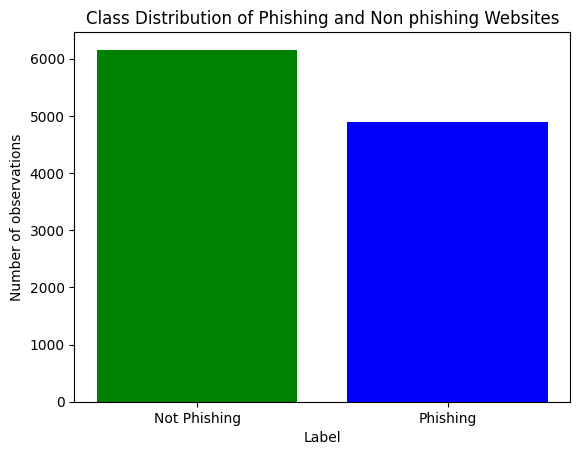

In [33]:

plt.bar(x = ["Not Phishing", "Phishing"], height=[y.value_counts()[1], y.value_counts()[0]], color=["green", "blue"])
plt.title("Class Distribution of Phishing and Non phishing Websites")
plt.ylabel("Number of observations")
plt.xlabel("Label")
plt.show()

In [34]:
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y.values, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)



In [35]:
train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val).float(),   torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test).float(),  torch.from_numpy(y_test))

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [36]:
input_dim = X_train.shape[1]
model = nn.Sequential(
    nn.Linear(input_dim, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)           
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [37]:

def evaluate(loader):
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb.float())
            total_loss += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            total_correct += (preds == yb).sum().item()
            total_count += xb.size(0)
    return total_loss / total_count, total_correct / total_count

epochs = 50
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_count = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb.float())
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        running_correct += (preds == yb).sum().item()
        running_count += xb.size(0)

    train_epoch_loss = running_loss / running_count
    train_epoch_acc  = running_correct / running_count
    val_epoch_loss, val_epoch_acc = evaluate(val_loader)

    history['train_loss'].append(train_epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['train_acc'].append(train_epoch_acc)
    history['val_acc'].append(val_epoch_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train_loss={train_epoch_loss:.4f} val_loss={val_epoch_loss:.4f} "
              f"train_acc={train_epoch_acc:.4f} val_acc={val_epoch_acc:.4f}")


Epoch 01/50 | train_loss=0.4348 val_loss=0.2039 train_acc=0.7535 val_acc=0.9180
Epoch 05/50 | train_loss=0.1483 val_loss=0.1584 train_acc=0.9391 val_acc=0.9299
Epoch 10/50 | train_loss=0.1229 val_loss=0.1395 train_acc=0.9510 val_acc=0.9373
Epoch 15/50 | train_loss=0.1071 val_loss=0.1271 train_acc=0.9577 val_acc=0.9480
Epoch 20/50 | train_loss=0.0948 val_loss=0.1269 train_acc=0.9624 val_acc=0.9480
Epoch 25/50 | train_loss=0.0867 val_loss=0.1164 train_acc=0.9642 val_acc=0.9520
Epoch 30/50 | train_loss=0.0814 val_loss=0.1239 train_acc=0.9655 val_acc=0.9480
Epoch 35/50 | train_loss=0.0766 val_loss=0.1153 train_acc=0.9685 val_acc=0.9520
Epoch 40/50 | train_loss=0.0732 val_loss=0.1085 train_acc=0.9692 val_acc=0.9593
Epoch 45/50 | train_loss=0.0707 val_loss=0.1104 train_acc=0.9705 val_acc=0.9542
Epoch 50/50 | train_loss=0.0688 val_loss=0.1148 train_acc=0.9719 val_acc=0.9599


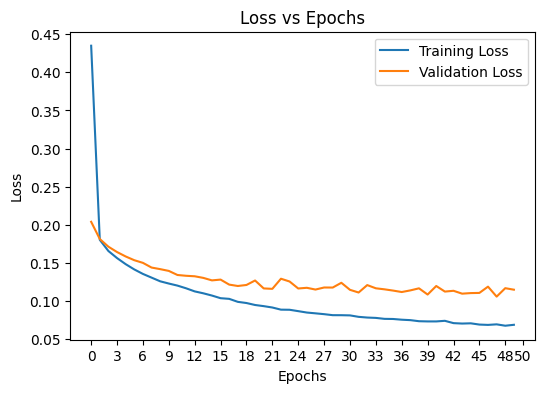

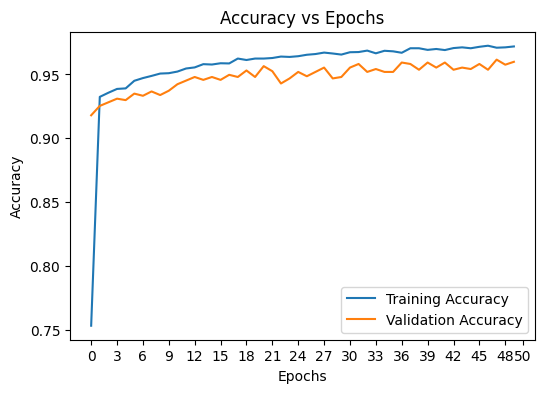

In [49]:
plt.figure(figsize=(6, 4))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss vs Epochs'); plt.legend()
ticks = list(range(0,51,3))
ticks.append(50)
plt.xticks(ticks)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy vs Epochs'); plt.legend()
plt.xticks(ticks)
plt.show()

In [39]:
final_train_ds = ConcatDataset([train_ds, val_ds])

final_train_loader = DataLoader(final_train_ds, batch_size=batch_size, shuffle=True)

In [40]:
input_dim = X_train.shape[1]
final_model = nn.Sequential(
    nn.Linear(input_dim, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)           
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3)

In [41]:
epochs = 47

for epoch in range(1, epochs+1):
    final_model.train()
    running_loss = 0.0
    running_correct = 0
    running_count = 0

    for xb, yb in final_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = final_model(xb)
        loss = criterion(logits, yb.float())
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        running_correct += (preds == yb).sum().item()
        running_count += xb.size(0)

    train_epoch_loss = running_loss / running_count
    train_epoch_acc  = running_correct / running_count


    if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train_loss={train_epoch_loss:.4f} | "
              f"train_acc={train_epoch_acc:.4f}")


Epoch 01/47 | train_loss=0.3122 | train_acc=0.8973
Epoch 05/47 | train_loss=0.1421 | train_acc=0.9430
Epoch 10/47 | train_loss=0.1142 | train_acc=0.9514
Epoch 15/47 | train_loss=0.0997 | train_acc=0.9586
Epoch 20/47 | train_loss=0.0897 | train_acc=0.9629
Epoch 25/47 | train_loss=0.0834 | train_acc=0.9660
Epoch 30/47 | train_loss=0.0781 | train_acc=0.9669
Epoch 35/47 | train_loss=0.0752 | train_acc=0.9714
Epoch 40/47 | train_loss=0.0729 | train_acc=0.9704
Epoch 45/47 | train_loss=0.0689 | train_acc=0.9716
Epoch 47/47 | train_loss=0.0689 | train_acc=0.9720


In [42]:
final_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = final_model(xb)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs > 0.5).astype(int)
        all_preds.extend(preds.tolist())
        all_true.extend(yb.numpy().ravel().astype(int).tolist())
        
print("Classification Report:")
print(classification_report(all_true, all_preds))


cm = confusion_matrix(all_true, all_preds)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       980
           1       0.96      0.98      0.97      1231

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



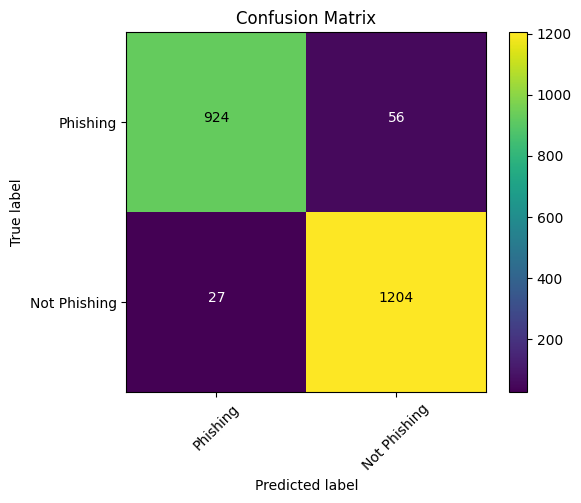

In [44]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Phishing', 'Not Phishing' ], rotation=45)
plt.yticks(tick_marks, ['Phishing', 'Not Phishing' ])
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "white")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()